<a href="https://colab.research.google.com/github/patrickkuiper/usma_courses/blob/main/Lesson_22_control_demo_complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
#must always do this first or it will cause issues with exisiting files in working directory
from google.colab import drive
#drive.mount('/content/drive')
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


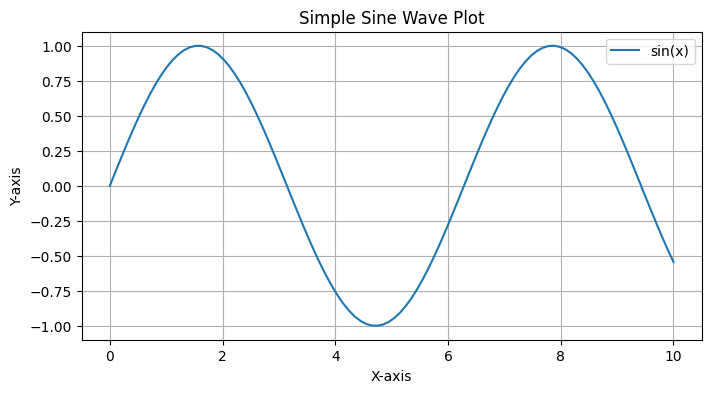

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Generate some simple data
x = np.linspace(0, 10, 100)
y = np.sin(x)

# Create the plot
plt.figure(figsize=(8, 4))
plt.plot(x, y, label='sin(x)')
plt.title('Simple Sine Wave Plot')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import os
import time
import joblib
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterGrid, cross_val_score
from tqdm.auto import tqdm
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split


from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier


In [ ]:
from tqdm.auto import tqdm
import time

In [ ]:
ts = time.time()
print(ts)
for i in tqdm(range(5)):
  time.sleep(2)
  print(i)
  if time.time() - ts > 8:
    break

In [ ]:
from tqdm.auto import tqdm
import time
time_now = time.time()
running_time = 0
#tqdm(grid, desc=f"Running {test_name}")
for i in tqdm(range(5)):
  time.sleep(2)
  print(i)
  running_time = time.time() - time_now
  if running_time > 8:
    break
total_time = time.time() - time_now
print(f"Total time taken: {total_time:.2f} seconds")

In [ ]:
# this block will save your test to a specific file path, created in-line
test_name = input("Enter the test name: ") # Input for the test name
CWD = f"/content/drive/MyDrive/Colab Notebooks/MA477_class_folder/Lesson_Notes/Lesson_22_Random_Forest/{test_name}"

# Ensure directory exists
if not os.path.exists(CWD):
    os.makedirs(CWD)

RUN_NAME = f"run_{test_name}_{time.strftime('%Y%m%d_%H%M%S')}"
LOG_PATH = os.path.join(CWD, f"{RUN_NAME}_log.csv")
BEST_MODEL_PATH = os.path.join(CWD, f"{RUN_NAME}_best_model.joblib")

print(f"Logging to: {LOG_PATH}")

In [ ]:
# Generate data and create a training and test split.
X, y = make_moons(n_samples=500, noise=0.30, random_state=477)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=477)
# Let's visualize the data.
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], color='orange', label='Class 0')
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color='blue', label='Class 1')
plt.title("Moon-Shaped Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid()
plt.show()

# Set up a search range for possible alpha values from 0.0001 to 1.
ccp_alphas = np.logspace(-1, 0, 1) #this is the weight of the regularization
n_est = np.arange(300, 600, 100) #this is the numnber of trees
# --- Grid Definition ---
param_grid = {
    'ccp_alpha': ccp_alphas,
    'n_estimators': n_est
}
grid = list(ParameterGrid(param_grid))
print(grid)

In [ ]:
grid_search = GridSearchCV(
    RandomForestClassifier(),
    param_grid={'ccp_alpha': ccp_alphas, 'n_estimators': np.arange(300, 600, 100)},
    cv=5,
    verbose=3  # Add this to see detailed logs
)
grid_search.fit(X_train,y_train)
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res
best_params = grid_search.best_params_
best_params

In [ ]:
results = []
best_score = -float('inf')

# --- Manual Loop with tqdm and Auto-Saving ---
for params in tqdm(grid, desc=f"Running {test_name}"):
    model = RandomForestClassifier(**params, n_jobs=-1)

    # Mimic GridSearchCV's 5-fold CV
    scores = cross_val_score(model, X_train, y_train, cv=5)
    mean_score = scores.mean()

    # Create result entry
    entry = {**params, 'mean_cv_score': mean_score, 'timestamp': time.time()}
    results.append(entry)

    # 1. Save/Update Log File (CSV) after every iteration
    pd.DataFrame(results).to_csv(LOG_PATH, index=False)

    # 2. Checkpoint: Save the best model found so far
    if mean_score > best_score:
        best_score = mean_score
        # Refit on all data before saving (mimics grid_search.best_estimator_)
        model.fit(X_train, y_train)
        joblib.dump(model, BEST_MODEL_PATH)

print(f"\nDone! Best Score: {best_score:.4f}")
print(f"Best model saved at: {BEST_MODEL_PATH}")


In [ ]:
# --- User Settings ---
MAX_MINUTES = 0.1  # Set your time limit here
start_time = time.time()
max_seconds = MAX_MINUTES * 60

In [ ]:
results = []
best_score = -float('inf')

# --- Manual Loop with Time Control ---
for params in tqdm(grid, desc=f"Running {test_name}"):
    # 1. Check Elapsed Time
    elapsed = time.time() - start_time
    if elapsed > max_seconds:
        print(f"\n[!] TIME LIMIT REACHED ({MAX_MINUTES} mins). Stopping search...")
        break

    # 2. Model Training & CV
    model = RandomForestClassifier(**params, n_jobs=-1)
    scores = cross_val_score(model, X_train, y_train, cv=5)
    mean_score = scores.mean()

    # 3. Log results
    entry = {**params, 'mean_cv_score': mean_score, 'elapsed_sec': round(time.time() - start_time, 2)}
    results.append(entry)
    pd.DataFrame(results).to_csv(LOG_PATH, index=False)

    # 4. Save best model
    if mean_score > best_score:
        best_score = mean_score
        model.fit(X_train, y_train)
        joblib.dump(model, BEST_MODEL_PATH)

# --- Final Printout ---
print("\n" + "="*30)
if len(results) > 0:
    print(f"PROCESS COMPLETED OR TIMED OUT")
    print(f"Best Score Found: {best_score:.4f}")
    print(f"Best Params: {next(item for item in results if item['mean_cv_score'] == best_score)}")
    print(f"Best model available at: {BEST_MODEL_PATH}")
else:
    print("No models were completed within the time limit.")
print("="*30)